In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy import linalg

S0 = 100.0
SIGMA = 0.2
R = 0.05
T = 1.0

a, fair value formula

In [5]:
def analytical_price(S0, sigma, r, T):
    sigma_eff = sigma * np.sqrt(2.0)
    d1 = 0.5 * sigma_eff * np.sqrt(T)
    d2 = -d1
    exchange = S0 * norm.cdf(d1) - S0 * norm.cdf(d2)
    return S0 + exchange

V_analytic = analytical_price(S0, SIGMA, R, T)
print(f"Analytical V(0) = {V_analytic:.4f}")

Analytical V(0) = 111.2463


c, PDE with Finite Difference method

In [ ]:
def get_d1(n):
    return 0.5 * (np.diag(np.ones(n-1), 1) - np.diag(np.ones(n-1), -1))

def get_d2(n):
    return np.diag(np.ones(n-1), 1) + np.diag(-2.*np.ones(n)) + np.diag(np.ones(n-1), -1)

def get_a(n, dx, r, sig):
    d  = -r * np.diag(np.ones(n))
    d1 = (r - 0.5*sig**2) / dx * get_d1(n)
    d2 = 0.5*sig**2 / dx**2 * get_d2(n)
    return d + d1 + d2

def solve_pde_cn(n_x=41, n_t=100):
    x_min, x_max = -1.5, 1.5
    dx = (x_max - x_min) / (n_x - 1)
    dt = T / (n_t - 1)
    x = np.linspace(x_min, x_max, n_x)
    S = S0 * np.exp(x)

    # Terminal condition
    S1g, S2g = np.meshgrid(S, S, indexing='ij')
    V = np.maximum(S1g, S2g)
    v = V.flatten()

    N = n_x * n_x
    A = np.kron(get_a(n_x, dx, R, SIGMA), np.eye(n_x)) + np.kron(np.eye(n_x), get_a(n_x, dx, R, SIGMA))
    I = np.eye(N)
    theta = 0.5
    M_left  = I - (1 - theta) * dt * A
    M_right = I + theta * dt * A

    interior = np.zeros((n_x, n_x), dtype=bool)
    interior[1:-1, 1:-1] = True
    idx = np.where(interior.flatten())[0]

    for _ in range(n_t - 1):
        rhs = M_right @ v
        v_boundary = v.copy()
        v_boundary[interior.flatten()] = 0
        rhs_int = rhs[idx] - (M_left @ v_boundary)[idx]
        v[idx] = linalg.solve(M_left[np.ix_(idx, idx)], rhs_int)

        V_new = v.reshape(n_x, n_x)
        V_new[0,  :] = S
        V_new[-1, :] = S[-1]
        V_new[:,  0] = S
        V_new[:, -1] = S[-1]
        v = V_new.flatten()

    return v.reshape(n_x, n_x), S

V_pde, S_axis = solve_pde_cn()
mid = len(S_axis) // 2
pde_price = V_pde[mid, mid]
print(f"PDE V(0) = {pde_price:.4f}")
print(f"Analytical V(0) = {V_analytic:.4f}")

Solving PDE...
PDE V(0) = 105.7458
Analytical V(0) = 111.2463


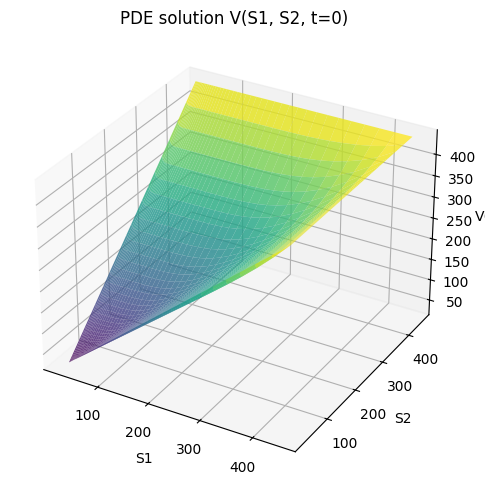

In [7]:
fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111, projection='3d')
S1g, S2g = np.meshgrid(S_axis, S_axis, indexing='ij')
ax.plot_surface(S1g, S2g, V_pde, cmap='viridis', alpha=0.8)
ax.set_xlabel('S1')
ax.set_ylabel('S2')
ax.set_zlabel('V(0)')
ax.set_title('PDE solution V(S1, S2, t=0)')
plt.tight_layout()
plt.show()

d, Monte Carlo

In [ ]:
def monte_carlo(S0, sigma, r, T, n_paths=100000):
    np.random.seed(42)
    Z1 = np.random.standard_normal(n_paths)
    Z2 = np.random.standard_normal(n_paths)
    S1_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z1)
    S2_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z2)
    payoff = np.maximum(S1_T, S2_T)
    price = np.exp(-r*T) * np.mean(payoff)
    std_err = np.exp(-r*T) * np.std(payoff) / np.sqrt(n_paths)
    return price, std_err

mc_price, mc_err = monte_carlo(S0, SIGMA, R, T)
print(f"Monte Carlo:  V(0) = {mc_price:.4f}  (+/- {1.96*mc_err:.4f})")
print(f"PDE (CN):     V(0) = {pde_price:.4f}")
print(f"Analytical:   V(0) = {V_analytic:.4f}")

In [ ]:
path_counts = [1000, 5000, 10000, 50000, 100000]
prices = [monte_carlo(S0, SIGMA, R, T, n)[0] for n in path_counts]

plt.figure(figsize=(7, 4))
plt.plot(path_counts, prices, 'o-', label='MC')
plt.axhline(V_analytic, color='r', linestyle='--', label=f'Analytical = {V_analytic:.3f}')
plt.axhline(pde_price, color='g', linestyle='--', label=f'PDE = {pde_price:.3f}')
plt.xscale('log')
plt.xlabel('Number of paths')
plt.ylabel('V(0)')
plt.title('MC convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()